In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/spelling_correct_with_removeNumber - spelling_correct_with_removeNumber.csv')
df

,sentence,labels
0,in going to go,0
1,in going to say goodby to the drugstore,0
2,i think that this is the way it should be done...,0
3,in going to join you,0
4,its illegal,0
...,...,...
25565,i saw that there are people like musfakur him ...,0
25566,papa she is trying to avoid responsibility here,0
25567,said needs the bangladesh team,0
25568,you keep going we ll take your shot,0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 69.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.1
    Uninstalling transformers-4.57.1:
      Successfully uninstalled transformers-4.57.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.17.0 which is incompatible.


Downloading:   0%|          | 0.00/972k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/625 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/681M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-multilingual-cased were not used when initializing BertForSequenceClassification: ['cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model ch

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.306000,0.277467,0.891474,0.900591,0.947606,0.858020
2,0.264900,0.247644,0.900665,0.911652,0.929433,0.894539
3,0.157200,0.272430,0.905162,0.915106,0.939274,0.892150
4,0.154000,0.296449,0.897927,0.911525,0.905387,0.917747
5,0.126200,0.321728,0.892843,0.907961,0.893849,0.922526
6,0.144600,0.369184,0.888932,0.905333,0.884691,0.926962
7,0.032800,0.419846,0.892257,0.906181,0.904179,0.908191
8,0.088400,0.445993,0.893430,0.907549,0.902192,0.912969


***** Running Evaluation *****
  Num examples = 5114
  Batch size = 32
Saving model checkpoint to ./results/checkpoint-640
Configuration saved in ./results/checkpoint-640/config.json
Model weights saved in ./results/checkpoint-640/pytorch_model.bin
***** Running Evaluation *****
  Num examples = 5114
  Batch size = 32
Saving model checkpoint to ./results/checkpoint-1280
Configuration saved in ./results/checkpoint-1280/config.json
Model weights saved in ./results/checkpoint-1280/pytorch_model.bin
***** Running Evaluation *****
  Num examples = 5114
  Batch size = 32
Saving model checkpoint to ./results/checkpoint-1920
Configuration saved in ./results/checkpoint-1920/config.json
Model weights saved in ./results/checkpoint-1920/pytorch_model.bin
***** Running Evaluation *****
  Num examples = 5114
  Batch size = 32
Saving model checkpoint to ./results/checkpoint-2560
Configuration saved in ./results/checkpoint-2560/config.json
Model weights saved in ./results/checkpoint-2560/pytorch_model

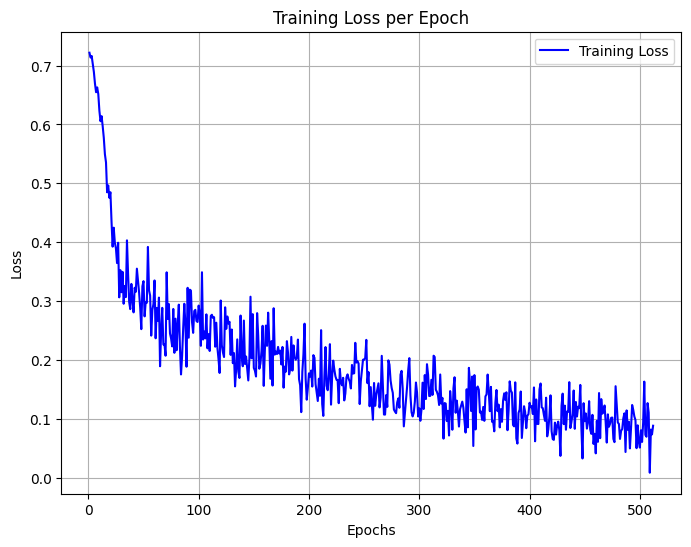

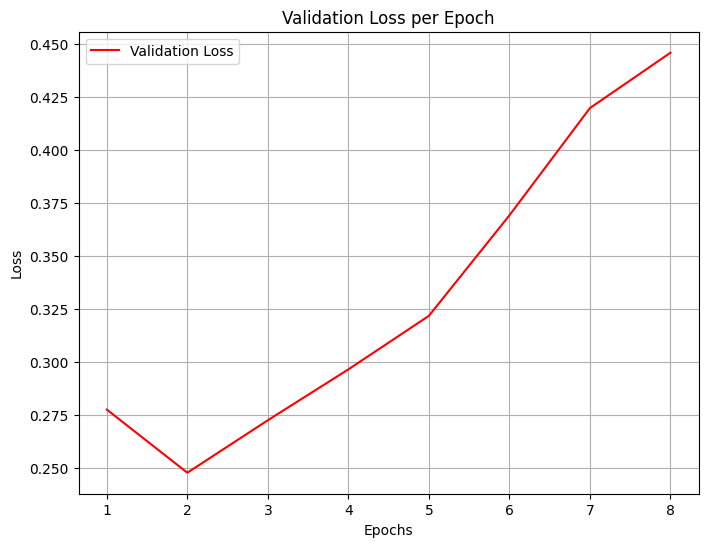

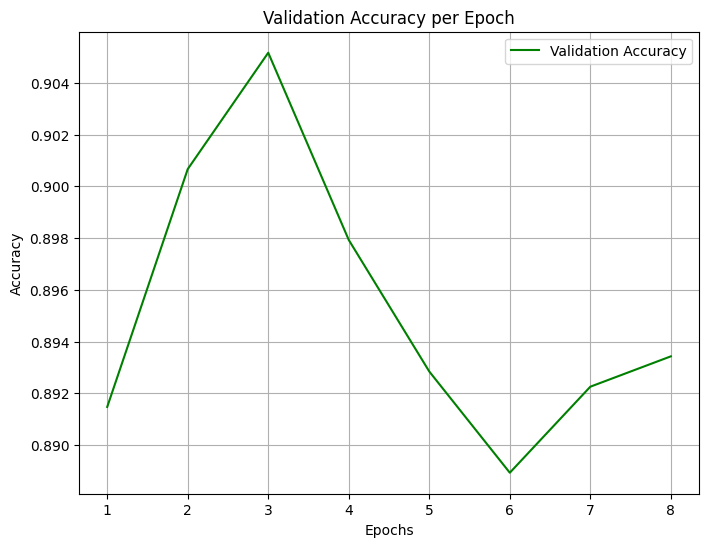

***** Running Prediction *****
  Num examples = 5114
  Batch size = 32


Evaluating model on test data...



Classification Report:
              precision    recall  f1-score   support

           0     0.8644    0.9226    0.8926      2184
           1     0.9393    0.8922    0.9151      2930

    accuracy                         0.9052      5114
   macro avg     0.9019    0.9074    0.9038      5114
weighted avg     0.9073    0.9052    0.9055      5114

✅ Test Accuracy: 0.9052


In [3]:
# Install necessary libraries
!pip install transformers==4.17 matplotlib pandas scikit-learn torch

# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, TrainerCallback
import torch
import os
import matplotlib.pyplot as plt
import pandas as pd

# Split into training and testing datasets
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['sentence'], df['labels'], test_size=0.2, random_state=42
)

# Load the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

# Tokenize the training and testing data
train_encodings = tokenizer(train_texts.astype(str).tolist(), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts.astype(str).tolist(), truncation=True, padding=True, max_length=128)

# Define a custom dataset class
class HateSpeechDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = pd.to_numeric(labels, errors='coerce').fillna(0).astype(int).tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create the datasets
train_dataset = HateSpeechDataset(train_encodings, train_labels)
test_dataset = HateSpeechDataset(test_encodings, test_labels)

# Disable WandB logging
os.environ["WANDB_DISABLED"] = "true"

# Define the compute_metrics function
def compute_metrics(p):
    preds = p.predictions.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, preds, average='binary')
    acc = accuracy_score(p.label_ids, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Initialize the model
model = BertForSequenceClassification.from_pretrained('bert-base-multilingual-cased', num_labels=2)

# Set up the training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=8,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    max_grad_norm=1.0,
    logging_dir='./logs',
    logging_steps=10,
    evaluation_strategy="epoch",  # Evaluate at the end of each epoch
    save_strategy="epoch",       # Save the model at the end of each epoch
    learning_rate=1e-5,
    lr_scheduler_type="linear",
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    disable_tqdm=False
)

# Define a custom callback to capture metrics per epoch
class MetricsHistoryCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.eval_losses = []
        self.eval_accuracies = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if "loss" in logs:
                self.train_losses.append(logs["loss"])
            if "eval_loss" in logs:
                self.eval_losses.append(logs["eval_loss"])
            if "eval_accuracy" in logs:
                self.eval_accuracies.append(logs["eval_accuracy"])

# Initialize the custom callback
metrics_callback = MetricsHistoryCallback()

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[metrics_callback]
)

# Train the model
trainer.train()

# Plot Training Loss
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(metrics_callback.train_losses) + 1), metrics_callback.train_losses, label='Training Loss', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Plot Validation Loss
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(metrics_callback.eval_losses) + 1), metrics_callback.eval_losses, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Validation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Plot Validation Accuracy
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(metrics_callback.eval_accuracies) + 1), metrics_callback.eval_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy per Epoch')
plt.legend()
plt.grid(True)
plt.show()


# ✅ Evaluate model and print classification report
print("Evaluating model on test data...")
predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

acc = accuracy_score(y_true, y_pred)
print(f"✅ Test Accuracy: {acc:.4f}")

In [9]:
# ===========================================
# 🚀 High Accuracy Hybrid Transformer Trainer
# Dataset: spelling_correct_with_removeNumber.csv
# ===========================================

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AdamW, get_linear_schedule_with_warmup
from tqdm import tqdm

# ===============================
# ⚙️ CONFIGURATION
# ===============================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 4
LR = 2e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================
# 📥 LOAD YOUR DATASET
# ===============================
file_path = "/content/spelling_correct_with_removeNumber - spelling_correct_with_removeNumber.csv"
df = pd.read_csv(file_path)

# Try to auto-detect text and label columns
possible_text_cols = [c for c in df.columns if "text" in c.lower() or "sentence" in c.lower()]
possible_label_cols = [c for c in df.columns if "label" in c.lower() or "category" in c.lower() or "class" in c.lower()]

text_col = possible_text_cols[0] if possible_text_cols else df.columns[0]
label_col = possible_label_cols[0] if possible_label_cols else df.columns[1]

print(f"Using text column: {text_col}")
print(f"Using label column: {label_col}")

texts = df[text_col].astype(str).tolist()
labels = df[label_col].astype(str).tolist()

# Encode labels into integers
le = LabelEncoder()
labels = le.fit_transform(labels)
num_labels = len(le.classes_)
print(f"Detected {num_labels} unique labels: {list(le.classes_)}")

# ===============================
# 🔀 TRAIN-VALIDATION SPLIT
# ===============================
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.1, random_state=42, stratify=labels
)

# ===============================
# 🧾 DATASET CLASS
# ===============================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

train_dataset = TextDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# ===============================
# 🧠 HYBRID MODEL DEFINITION
# ===============================
from transformers import AutoModel

class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionLayer, self).__init__()
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, hidden_states):
        attn_weights = torch.softmax(self.attention(hidden_states), dim=1)
        weighted_output = torch.sum(hidden_states * attn_weights, dim=1)
        return weighted_output, attn_weights

class CustomHybridBERT(nn.Module):
    def __init__(self, model_name=MODEL_NAME, num_labels=num_labels, lstm_units=256, dropout_rate=0.4):
        super(CustomHybridBERT, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.lstm = nn.LSTM(hidden_size, lstm_units, bidirectional=True, batch_first=True)
        self.attention = AttentionLayer(lstm_units * 2)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_units * 2, lstm_units),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.LayerNorm(lstm_units),
            nn.Linear(lstm_units, num_labels)
        )

    def forward(self, input_ids, attention_mask):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = bert_output.last_hidden_state
        lstm_output, _ = self.lstm(hidden_states)
        attn_output, _ = self.attention(lstm_output)
        logits = self.classifier(attn_output)
        return logits

# ===============================
# ⚡ TRAINING SETUP
# ===============================
model = CustomHybridBERT(num_labels=num_labels).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
criterion = nn.CrossEntropyLoss()

# ===============================
# 🔁 TRAINING LOOP
# ===============================
def train_epoch(model, data_loader, optimizer, criterion):
    model.train()
    total_loss, total_correct = 0, 0
    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total_correct += (preds == labels).sum().item()
    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

def eval_epoch(model, data_loader, criterion):
    model.eval()
    total_loss, total_correct = 0, 0
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Validation"):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            total_correct += (preds == labels).sum().item()
    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

# ===============================
# 🧩 TRAINING START
# ===============================
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

# ===============================
# 💾 SAVE MODEL
# ===============================
torch.save(model.state_dict(), "custom_hybrid_model.pt")
print("✅ Model saved successfully!")


Using text column: sentence
Using label column: labels
Detected 2 unique labels: [np.str_('0'), np.str_('1')]


loading configuration file https://huggingface.co/distilbert-base-uncased/resolve/main/config.json from cache at /root/.cache/huggingface/transformers/23454919702d26495337f3da04d1655c7ee010d5ec9d77bdb9e399e00302c0a1.91b885ab15d631bf9cee9dc9d25ece0afd932f2f5130eba28f2055b2220c0333
Model config DistilBertConfig {
  "_name_or_path": "distilbert-base-uncased",
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "dim": 768,
  "dropout": 0.1,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "transformers_version": "4.17.0",
  "vocab_size": 30522
}

loading file https://huggingface.co/distilbert-base-uncased/resolve/main/vocab.txt from cache at /root/.cache/huggingface/transformers/0e1bbfda7f63a99bb52e3915dcf10


Epoch 1/4


Validation: 100%|██████████| 160/160 [00:10<00:00, 15.70it/s]


Train Loss: 0.2903 | Train Acc: 88.22%
Val Loss:   0.2753 | Val Acc:   90.14%

Epoch 2/4


...

Train Loss: 0.2039 | Train Acc: 92.62%
Val Loss:   0.2997 | Val Acc:   89.91%

Epoch 3/4


Validation: 100%|██████████| 160/160 [00:10<00:00, 15.70it/s]


Train Loss: 0.1454 | Train Acc: 94.92%
Val Loss:   0.3076 | Val Acc:   91.16%

Epoch 4/4


Validation: 100%|██████████| 160/160 [00:10<00:00, 15.72it/s]


Train Loss: 0.0935 | Train Acc: 96.89%
Val Loss:   0.3348 | Val Acc:   90.54%
✅ Model saved successfully!


In [16]:
def eval_epoch(model, data_loader, criterion):
    model.eval()
    total_loss, total_correct = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Validation"):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            total_correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset), all_preds, all_labels
val_loss, val_acc, preds, true_labels = eval_epoch(model, val_loader, criterion)

from sklearn.metrics import classification_report

report = classification_report(true_labels, preds, target_names=le.classes_)
print("✅ Classification Report:\n")
print(report)


Validation: 100%|██████████| 160/160 [00:10<00:00, 15.55it/s]

✅ Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1101
           1       0.90      0.93      0.92      1456

    accuracy                           0.91      2557
   macro avg       0.91      0.90      0.90      2557
weighted avg       0.91      0.91      0.91      2557



Using text column: sentence
Using label column: labels
Detected 2 unique labels: [np.str_('0'), np.str_('1')]


loading configuration file https://huggingface.co/distilbert-base-uncased/resolve/main/config.json from cache at /root/.cache/huggingface/transformers/23454919702d26495337f3da04d1655c7ee010d5ec9d77bdb9e399e00302c0a1.91b885ab15d631bf9cee9dc9d25ece0afd932f2f5130eba28f2055b2220c0333
Model config DistilBertConfig {
  "_name_or_path": "distilbert-base-uncased",
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "dim": 768,
  "dropout": 0.1,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "transformers_version": "4.17.0",
  "vocab_size": 30522
}

loading file https://huggingface.co/distilbert-base-uncased/resolve/main/vocab.txt from cache at /root/.cache/huggingface/transformers/0e1bbfda7f63a99bb52e3915dcf10


Epoch 1/10


Validation: 100%|██████████| 320/320 [00:20<00:00, 15.66it/s]


Train Loss: 0.2952 | Train Acc: 87.84%
Val Loss:   0.2407 | Val Acc:   90.91%

Epoch 2/10


...

Train Loss: 0.0275 | Train Acc: 99.11%
Val Loss:   0.6507 | Val Acc:   90.65%

Epoch 9/10


Validation: 100%|██████████| 320/320 [00:20<00:00, 15.73it/s]


Train Loss: 0.0200 | Train Acc: 99.32%
Val Loss:   0.6136 | Val Acc:   89.64%

Epoch 10/10


Validation: 100%|██████████| 320/320 [00:20<00:00, 15.69it/s]


Train Loss: 0.0187 | Train Acc: 99.46%
Val Loss:   0.6852 | Val Acc:   90.69%


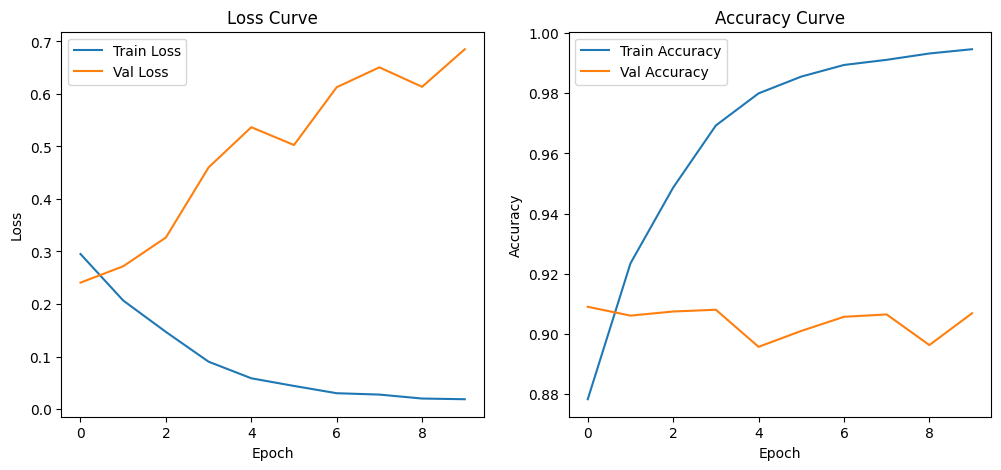


✅ Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      2201
           1       0.93      0.91      0.92      2913

    accuracy                           0.91      5114
   macro avg       0.90      0.91      0.91      5114
weighted avg       0.91      0.91      0.91      5114



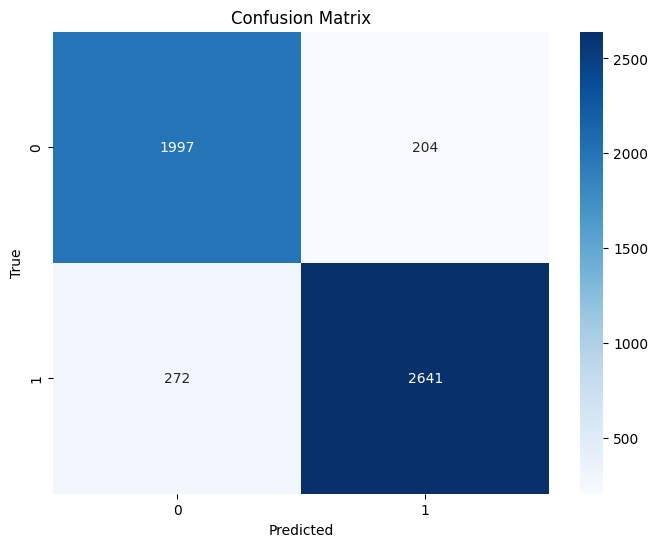

✅ Model saved successfully with metrics!


In [17]:
# ===========================================
# 🚀 High Accuracy Hybrid Transformer Trainer
# Dataset: spelling_correct_with_removeNumber.csv
# ===========================================

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModel, AdamW, get_linear_schedule_with_warmup
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ===============================
# ⚙️ CONFIGURATION
# ===============================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 10
LR = 2e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================
# 📥 LOAD DATASET
# ===============================
file_path = "/content/spelling_correct_with_removeNumber - spelling_correct_with_removeNumber.csv"
df = pd.read_csv(file_path)

# Auto-detect text and label columns
possible_text_cols = [c for c in df.columns if "text" in c.lower() or "sentence" in c.lower()]
possible_label_cols = [c for c in df.columns if "label" in c.lower() or "category" in c.lower() or "class" in c.lower()]

text_col = possible_text_cols[0] if possible_text_cols else df.columns[0]
label_col = possible_label_cols[0] if possible_label_cols else df.columns[1]

print(f"Using text column: {text_col}")
print(f"Using label column: {label_col}")

texts = df[text_col].astype(str).tolist()
labels = df[label_col].astype(str).tolist()

# Encode labels into integers
le = LabelEncoder()
labels = le.fit_transform(labels)
num_labels = len(le.classes_)
print(f"Detected {num_labels} unique labels: {list(le.classes_)}")

# ===============================
# 🔀 TRAIN-VALIDATION SPLIT
# ===============================
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# ===============================
# 🧾 DATASET CLASS
# ===============================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

train_dataset = TextDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# ===============================
# 🧠 HYBRID MODEL DEFINITION
# ===============================
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionLayer, self).__init__()
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, hidden_states):
        attn_weights = torch.softmax(self.attention(hidden_states), dim=1)
        weighted_output = torch.sum(hidden_states * attn_weights, dim=1)
        return weighted_output, attn_weights

class CustomHybridBERT(nn.Module):
    def __init__(self, model_name=MODEL_NAME, num_labels=num_labels, lstm_units=256, dropout_rate=0.4):
        super(CustomHybridBERT, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.lstm = nn.LSTM(hidden_size, lstm_units, bidirectional=True, batch_first=True)
        self.attention = AttentionLayer(lstm_units * 2)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_units * 2, lstm_units),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.LayerNorm(lstm_units),
            nn.Linear(lstm_units, num_labels)
        )

    def forward(self, input_ids, attention_mask):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = bert_output.last_hidden_state
        lstm_output, _ = self.lstm(hidden_states)
        attn_output, _ = self.attention(lstm_output)
        logits = self.classifier(attn_output)
        return logits

# ===============================
# ⚡ TRAINING SETUP
# ===============================
model = CustomHybridBERT(num_labels=num_labels).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
criterion = nn.CrossEntropyLoss()

# ===============================
# 🔁 TRAINING FUNCTIONS
# ===============================
def train_epoch(model, data_loader, optimizer, criterion):
    model.train()
    total_loss, total_correct = 0, 0
    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total_correct += (preds == labels).sum().item()
    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

def eval_epoch(model, data_loader, criterion):
    model.eval()
    total_loss, total_correct = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Validation"):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            total_correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset), all_preds, all_labels

# ===============================
# 🧩 TRAINING LOOP
# ===============================
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, preds, true_labels = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

# ===============================
# 📈 PLOT LOSS & ACCURACY CURVES
# ===============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# ===============================
# 📊 CLASSIFICATION REPORT
# ===============================
print("\n✅ Classification Report:\n")
print(classification_report(true_labels, preds, target_names=le.classes_))

# ===============================
# 🟦 CONFUSION MATRIX
# ===============================
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ===============================
# 💾 SAVE MODEL
# ===============================
torch.save(model.state_dict(), "custom_hybrid_model_with_metrics.pt")
print("✅ Model saved successfully with metrics!")


In [ ]:
# ===========================================
# 🚀 Improved Hybrid Transformer Trainer
# Dataset: spelling_correct_with_removeNumber.csv
# ===========================================

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModel, AdamW, get_linear_schedule_with_warmup
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ===============================
# CONFIGURATION
# ===============================
MODEL_NAME = "bert-base-uncased"  # Upgraded to full BERT
MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS = 10  # more epochs for better learning
LR = 2e-5
LSTM_UNITS = 512
DROPOUT_RATE = 0.4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================
# LOAD DATASET
# ===============================
file_path = "/content/spelling_correct_with_removeNumber - spelling_correct_with_removeNumber.csv"
df = pd.read_csv(file_path)

possible_text_cols = [c for c in df.columns if "text" in c.lower() or "sentence" in c.lower()]
possible_label_cols = [c for c in df.columns if "label" in c.lower() or "category" in c.lower() or "class" in c.lower()]

text_col = possible_text_cols[0] if possible_text_cols else df.columns[0]
label_col = possible_label_cols[0] if possible_label_cols else df.columns[1]

texts = df[text_col].astype(str).tolist()
labels = df[label_col].astype(str).tolist()

# Encode labels
le = LabelEncoder()
labels = le.fit_transform(labels)
num_labels = len(le.classes_)

# Train-validation split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# ===============================
# DATASET CLASS
# ===============================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

train_dataset = TextDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# ===============================
# MODEL DEFINITION
# ===============================
class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionLayer, self).__init__()
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, hidden_states):
        attn_weights = torch.softmax(self.attention(hidden_states), dim=1)
        weighted_output = torch.sum(hidden_states * attn_weights, dim=1)
        return weighted_output, attn_weights

class CustomHybridBERT(nn.Module):
    def __init__(self, model_name=MODEL_NAME, num_labels=num_labels, lstm_units=LSTM_UNITS, dropout_rate=DROPOUT_RATE):
        super(CustomHybridBERT, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.lstm = nn.LSTM(hidden_size, lstm_units, bidirectional=True, batch_first=True)
        self.attention = AttentionLayer(lstm_units * 2)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_units * 2, lstm_units),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.LayerNorm(lstm_units),
            nn.Linear(lstm_units, num_labels)
        )

    def forward(self, input_ids, attention_mask):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = bert_output.last_hidden_state
        lstm_output, _ = self.lstm(hidden_states)
        attn_output, _ = self.attention(lstm_output)
        logits = self.classifier(attn_output)
        return logits

# ===============================
# TRAINING SETUP
# ===============================
model = CustomHybridBERT().to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
criterion = nn.CrossEntropyLoss()

# ===============================
# TRAIN & EVAL FUNCTIONS
# ===============================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct = 0, 0
    for batch in tqdm(loader, desc="Training"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total_correct += (preds == labels).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_correct = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation"):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            total_correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), total_correct / len(loader.dataset), all_preds, all_labels

# ===============================
# TRAINING LOOP
# ===============================
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_acc = 0
best_model_path = "best_hybrid_model.pt"

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, preds, true_labels = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Best model saved at epoch {epoch+1} with Val Acc: {best_val_acc*100:.2f}%")

# ===============================
# PLOT LOSS & ACCURACY
# ===============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# ===============================
# CLASSIFICATION REPORT
# ===============================
print("\n✅ Classification Report:\n")
print(classification_report(true_labels, preds, target_names=le.classes_))

# ===============================
# CONFUSION MATRIX
# ===============================
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


loading configuration file https://huggingface.co/bert-base-uncased/resolve/main/config.json from cache at /root/.cache/huggingface/transformers/3c61d016573b14f7f008c02c4e51a366c67ab274726fe2910691e2a761acf43e.37395cee442ab11005bcd270f3c34464dc1704b715b5d7d52b1a461abe3b9e4e
Model config BertConfig {
  "_name_or_path": "bert-base-uncased",
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.17.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

loading file https://huggingface.co/bert-base-uncased/resolve/ma


Epoch 1/10


Validation: 100%|██████████| 320/320 [01:22<00:00,  3.86it/s]


Train Loss: 0.2960 | Train Acc: 88.31%
Val Loss:   0.2765 | Val Acc:   90.63%
✅ Best model saved at epoch 1 with Val Acc: 90.63%

Epoch 2/10


Validation: 100%|██████████| 320/320 [01:22<00:00,  3.86it/s]


...

Validation: 100%|██████████| 320/320 [01:22<00:00,  3.88it/s]


Train Loss: 0.0351 | Train Acc: 99.20%
Val Loss:   0.8436 | Val Acc:   90.65%

Epoch 9/10


Validation: 100%|██████████| 320/320 [01:22<00:00,  3.89it/s]


Train Loss: 0.0335 | Train Acc: 99.28%
Val Loss:   0.8641 | Val Acc:   90.20%

Epoch 10/10


Training:  11%|█         | 142/1279 [01:47<14:24,  1.32it/s]